# Assignment 3: LLMs and Machine Learning

---

## Submission Instructions

Submit only a link to the folder for Assignment 3 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment3.ipynb` or something similar, placed inside the `assignments/assignment3/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Code Quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between tasks.
- Print out your answers so that the peer reviewer can see the results. Use the `df.head()` when asked to print the top  5 lines. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per task, and when reasonable, separate cells for subtasks.
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

## Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title

## Statement of use of AI

Include a brief statement describing how and which AI was used (or if no AI was used) in completing the assignment. This could be a markdown cell with a couple of sentences. As a reminder, AI use is permitted in the assignments, but it is advisable to try to complete the tasks as far as possible without and to make sure you understand the code that AI produced when using it.

I used the claude AI to assist me with the assignment. For task0-2, I used it to debuff and generate the text for "prompt". But for task3, since I really had no choice and missed the couse and the deadline for assignment3 is this week, it is too difficult for me to complete it by my own. so I used claude to generate the codes for me and teach me what is the code doing and why we should do it.


## Grading

This assignment is worth 10 points. Task 0 is worth 1 point, and tasks 1-2 are worth 2 points and task 3 is worth 5 points.

Points are given only for code that runs. If the code does not run, the task (or subtask if code for a task is divided into multiple cells) will automatically receive 0 points even if the code is almost correct.

### Penalties

- **-2 points per task** where AI-generated (hallucinated) data is used instead of the actual data provided in the task or retrieved from the specified source. The assignment requires working with real data, not made-up values!
- **-3 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all tasks are completed within one cell, if answers are difficult to find due to too much irrelevant printed output).
- **-1 point** if there is no statement of AI use. If you did not use AI, report that you did not use AI.

### Editing the submission after the deadline

- Editing the assignment submission during the evaluation phase is forbidden. Thus, after the solution has been released, do not make any further changes to the notebook until you have received a grade. If you accidentally leaked an API key, revoke the key immediately. Other **changes to the submission are considered cheating, and will result in 0 points for both the assignment and peer review**.

---

## Tasks

### Task 0: Setting up Ollama (1p)

a) Set up Ollama and connect to it using either openAI's API or Ollama's own API. 

b) Load the 270m parameter version of the [gemma3](https://ollama.com/library/gemma3) model and test it with any prompt.

c) Load the 4b parameter version of the [gemma3](https://ollama.com/library/gemma3) and test it with any prompt. If running the 4b version is too slow, you can use the 1b version instead.

In [2]:
pip install ollama

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import ollama
#test the gemma3:1b model

response = ollama.chat(         #library also calls the ollama local API at the bottom layer
    model="gemma3:1b",          # use gemma3:1b model
    messages=[                   
        {
            "role": "user",      
            "content": "Do you prefer cats or dogs?"  
        }
    ]
)
print(response["message"]["content"])

As an AI, I don’t have preferences like humans do! But… if I *were* to choose, based on the information I’ve been trained on, I’d have to say I’d lean towards **dogs**. 

Here’s why, from a data perspective:

*   **Loyalty & Companionship:** Dogs are often associated with unwavering loyalty and a desire to please.
*   **Playfulness & Enthusiasm:** Their energy and enthusiasm are frequently cited as charming.
*   **Variety:** There’s such a massive range of dog breeds to choose from, offering incredible variety in personality and appearance.

However, that doesn't mean I don't appreciate cats! They have a quiet and gentle charm. 

**Ultimately, it’s a matter of personal preference!** 

Do you have a favorite type of pet? I’d love to hear about it!


In [9]:
response = ollama.chat(
    model = "gemma3:270m",
    messages = [{"role":"user","content":"who are you?"}]
)
print(response["message"]["content"])


I am Gemma, an open-weights AI assistant. I am a large language model created by the Gemma team at Google DeepMind.



In [10]:
response = ollama.chat(
    model="gemma3:4b",          # use gemma3:4b model
    messages=[{"role":"user","content":"where can I hike in Helsinki?"}]
)
print(response["message"]["content"])


Okay, Helsinki offers a surprising amount of fantastic hiking opportunities! Here's a breakdown of great options, categorized by difficulty and what you can expect:

**1. Easy & Accessible - Great for Families & Beginners:**

* **Suomenlinna Fortress Trails:** (Approx. 2-4 hours) - This UNESCO World Heritage Site is a must-do.  It’s a sea fortress on a group of islands and offers a network of trails around the walls, through the historic buildings, and into the surrounding nature.  You can easily customize your hike based on how much of the fortress you want to explore. There are paved and gravel paths, making it accessible for most.
    * **Website:** [https://www.suomenlinna.fi/en/](https://www.suomenlinna.fi/en/)
* **Vallisaari Island Trails:** (Approx. 1-3 hours) - Another island, Vallisaari, offers a slightly wilder experience than Suomenlinna. Trails here are often unpaved and more natural. You'll find art installations, a former military base, and beautiful views. Ferries run re

### Task 1: Text classification with Ollama (2p)

The `data/emails.csv` file contains 12 email headlines, with 4 spam emails, 4 legitimate work emails and 4 vague emails that are hard to classify based on the title alone. Use this dataset for all subtasks in this task.

a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. The function should return only the classification and nothing else. (0.5p)

b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)

c) Use larger gemma3 (4b) to classify the emails using the function created in part a). In separate markdown cell, write a brief comment comparing the results of parts b) and c). (0.5p)

d) Write a script that repeats b) and c) 3 times, storing the results for both models separately. For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models. Comment if there were differences and explain why this happened. (0.5p)

In [51]:
#1a)
import pandas as pd
df_emails = pd.read_csv(r"C:\Users\11317\Downloads\emails.csv", encoding="latin-1")  #"utf-8"cannot recognize"€"
display(df_emails)

def classify_email(headline, model):
    
    prompt = f"""Classify the following email headline into exactly one of these categories: spam, work, or unknown.

- spam: unsolicited commercial or scam emails
- work: legitimate professional/work-related emails
- unknown: unclear or ambiguous emails

Reply with ONLY one word: spam, work, or unknown. No explanation.

Email headline: "{headline}"
"""
    
    response = ollama.chat(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    
    result = response["message"]["content"].strip().lower().split()[0]
    
    if result not in ["spam", "work", "unknown"]:
        return "unknown"
    
    return result

,headline,Unnamed: 1
0,URGENT: Your account will be suspended within ...,NaN
1,Congratulations! You have won a 1000gift card,claim now
2,Hot singles in your area are waiting to meet y...,NaN
3,Re: Inheritance transfer of 4.5M USD pending y...,NaN
4,Meeting agenda for Thursday's project review,NaN
5,Q3 budget report attached,please review by Friday
6,Reminder: Annual performance review scheduled ...,NaN
7,Updated draft of the manuscript,comments welcome
8,Quick question about last week,NaN
9,Following up,NaN


In [52]:
#1b)

df_emails = df_emails.reset_index(drop=True) #read from the first line
df_emails["classification_270m"] = df_emails["headline"].apply(
    lambda x: classify_email(x, "gemma3:270m")
)
display(df_emails)

,headline,Unnamed: 1,classification_270m
0,URGENT: Your account will be suspended within ...,NaN,spam
1,Congratulations! You have won a 1000gift card,claim now,spam
2,Hot singles in your area are waiting to meet y...,NaN,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,NaN,spam
4,Meeting agenda for Thursday's project review,NaN,spam
5,Q3 budget report attached,please review by Friday,spam
6,Reminder: Annual performance review scheduled ...,NaN,spam
7,Updated draft of the manuscript,comments welcome,spam
8,Quick question about last week,NaN,spam
9,Following up,NaN,spam


In [53]:
#1c)
df_emails["classification_4b"] = df_emails["headline"].apply(
    lambda x: classify_email(x, "gemma3:4b")
)

display(df_emails)

,headline,Unnamed: 1,classification_270m,classification_4b
0,URGENT: Your account will be suspended within ...,NaN,spam,spam
1,Congratulations! You have won a 1000gift card,claim now,spam,spam
2,Hot singles in your area are waiting to meet y...,NaN,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,NaN,spam,spam
4,Meeting agenda for Thursday's project review,NaN,spam,work
5,Q3 budget report attached,please review by Friday,spam,work
6,Reminder: Annual performance review scheduled ...,NaN,spam,work
7,Updated draft of the manuscript,comments welcome,spam,work
8,Quick question about last week,NaN,spam,unknown
9,Following up,NaN,spam,work


270m model classified all 12 emails as spam and had no ability to distinguish them at all.
4b model can accurately identify work emails (lines 4-7) and difficult-to-distinguish emails (lines 8, 11).
The clear spam emails (lines 0-3) are also classified correctly.

In [54]:
#1d)
results_270m = {}
results_4b = {}

for run in range(1, 4):
    print(f"the {run} run...")
    
    results_270m[f"run_{run}"] = df_emails["headline"].apply(
        lambda x: classify_email(x, "gemma3:270m")
    )
    results_4b[f"run_{run}"] = df_emails["headline"].apply(
        lambda x: classify_email(x, "gemma3:4b")
    )

df_270m_runs = pd.DataFrame({                #merge into a table
    "headline": df_emails["headline"],
    **results_270m
})

df_4b_runs = pd.DataFrame({
    "headline": df_emails["headline"],
    **results_4b
})

print("=== 270m results ===")
display(df_270m_runs)

print("=== 4b results ===")
display(df_4b_runs)

the 1 run...
the 2 run...
the 3 run...
=== 270m results ===


,headline,run_1,run_2,run_3
0,URGENT: Your account will be suspended within ...,spam,spam,spam
1,Congratulations! You have won a 1000gift card,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam
4,Meeting agenda for Thursday's project review,spam,spam,spam
5,Q3 budget report attached,spam,spam,spam
6,Reminder: Annual performance review scheduled ...,spam,spam,spam
7,Updated draft of the manuscript,spam,spam,spam
8,Quick question about last week,spam,spam,spam
9,Following up,spam,spam,spam


=== 4b results ===


,headline,run_1,run_2,run_3
0,URGENT: Your account will be suspended within ...,spam,spam,spam
1,Congratulations! You have won a 1000gift card,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam
4,Meeting agenda for Thursday's project review,work,work,work
5,Q3 budget report attached,work,work,work
6,Reminder: Annual performance review scheduled ...,work,work,work
7,Updated draft of the manuscript,work,work,work
8,Quick question about last week,unknown,unknown,unknown
9,Following up,work,work,work


The results of the two models were exactly the same in three runs, with no changes. The model output is stable. The overall accuracy of 4b is significantly higher than that of 270m because more parameters enable it to better understand the semantic meaning of the text.

### Task 2: Sentiment analysis with Ollama (2p)

The `data/news.csv` file contains 10 fictional financial news headlines. Use it for all subtasks in this task.

a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). The function should return the class and sentiment in JSON format. (1p)

b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options. Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p)

In [71]:
#2a)
import json
df_news = pd.read_csv(r"C:\Users\11317\Downloads\news.csv") 
display(df_news)

def classify_news (headline, model="gemma3:4b"):
    
    prompt = f"""Analyze the following financial news headline.

Return ONLY a JSON object with exactly these two fields:
- "topic": one of [earnings, mergers, regulation, macroeconomics]
- "sentiment": one of [positive, negative, neutral]

No explanation. No markdown. Just the JSON object.

Headline: "{headline}"
"""
    
    response = ollama.chat(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    raw = response["message"]["content"].strip()  #delete the spaces
    
    raw = raw.replace("```json", "").replace("```", "").strip()  # eliminate the ```json ... ``` in the returned results of task 2b
    try:
        result = json.loads(raw)
    except json.JSONDecodeError:
        result = {"topic": "unknown", "sentiment": "unknown"}  # If fail, return the default value "unknown" 
    
    return result
    
    

,headline,subtitle
0,Nordion Industries beats Q1 earnings estimates...,NaN
1,Helvora Pharmaceuticals misses earnings foreca...,NaN
2,Aurelis Bank reports steady quarterly profit,in line with analyst expectations
3,Veridyne Logistics to acquire rival Trantec in...,NaN
4,Antitrust regulators block proposed merger bet...,NaN
5,Kestrel Semiconductor confirms early-stage mer...,NaN
6,New EU AI Act compliance rules expected to rai...,NaN
7,Finnish FSA grants Norvik Capital expanded lic...,NaN
8,Eurozone inflation cools to 2.1%,easing pressure on Drava Holdings borrowing c...
9,Rising interest rates weigh on Tessaro Real Es...,NaN


In [72]:
#2b)
analyses = df_news["headline"].apply(lambda x: classify_news(x, "gemma3:4b"))

df_news["topic"] = analyses.apply(lambda x: x.get("topic", "unknown"))
df_news["sentiment"] = analyses.apply(lambda x: x.get("sentiment", "neutral"))

display(df_news)


,headline,subtitle,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,NaN,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,NaN,earnings,negative
2,Aurelis Bank reports steady quarterly profit,in line with analyst expectations,earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,NaN,mergers,positive
4,Antitrust regulators block proposed merger bet...,NaN,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,NaN,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,NaN,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,NaN,regulation,positive
8,Eurozone inflation cools to 2.1%,easing pressure on Drava Holdings borrowing c...,macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,NaN,macroeconomics,negative


#2c) result from claude

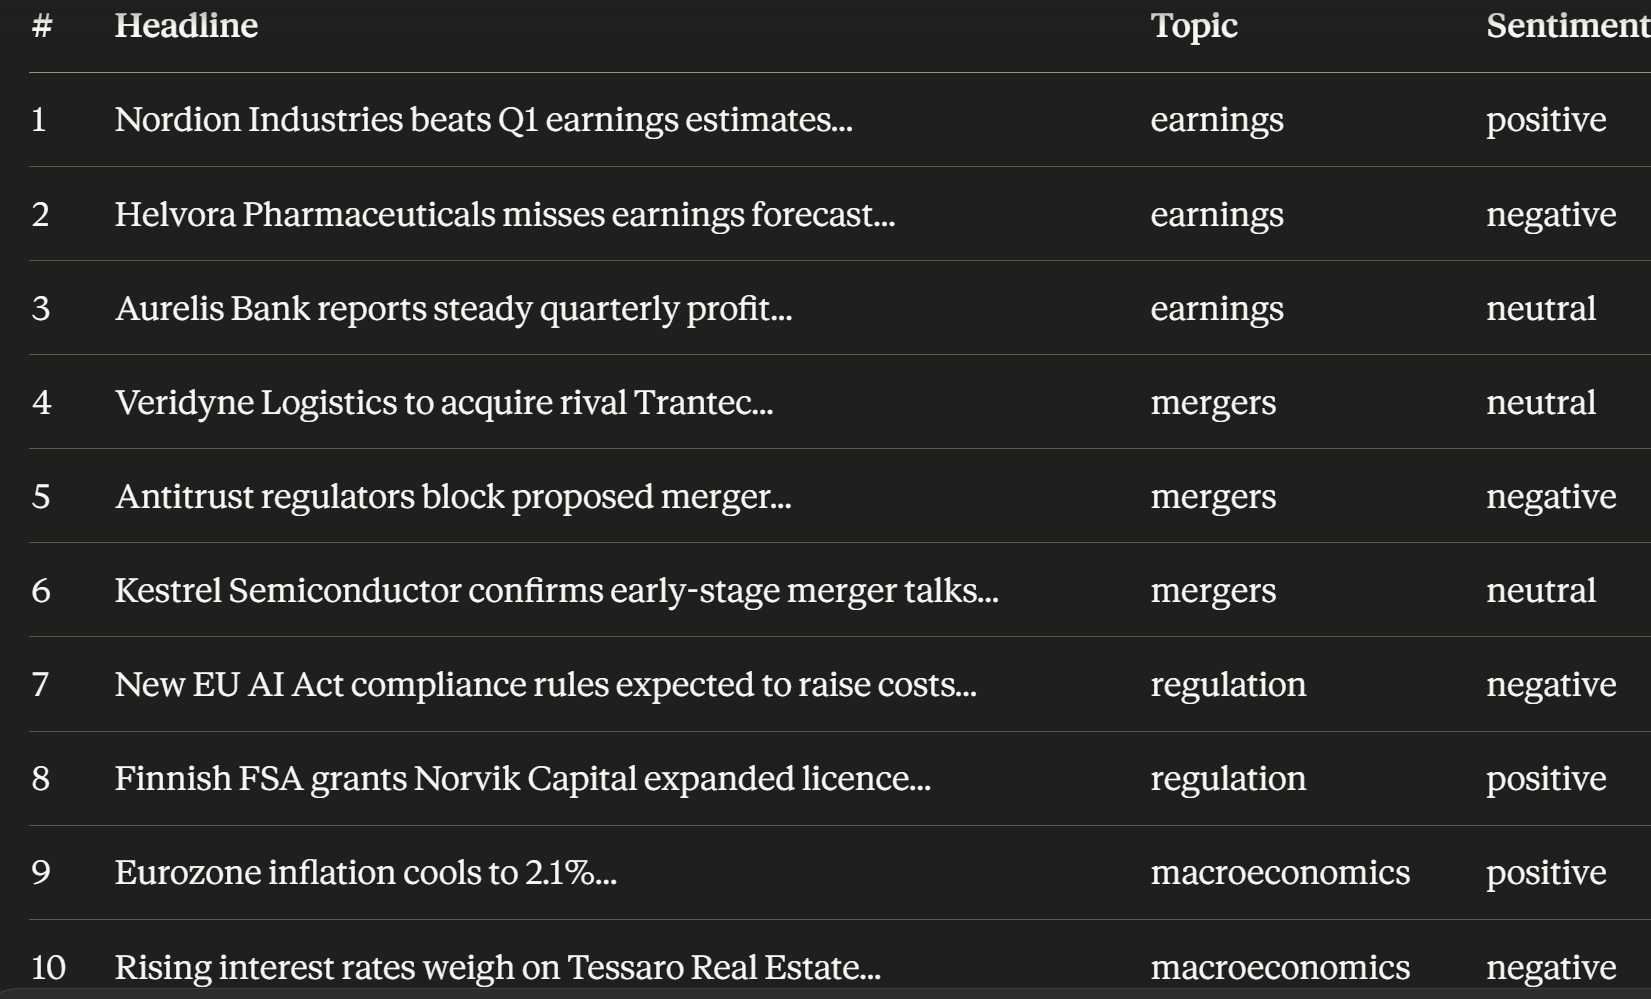

In terms of Topic classification, most of the two models are consistent. Only the fourth line (Antitrust regulators block
...) is different. This piece of news involves both regulatory actions and merger and acquisition events, and both classifications make sense.
Sentiment analysis: Claude is more conservative and accurate in the segmentation of sentiment.
4b model tends to classify ambiguous situations as positive.



### Task 3: Supervised machine learning (5p)

For this task, use a subset of the [Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) dataset, by downloading and importing the `bank-additional.csv` from the UCI repository. You can find a description of the dataset behind the link.

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).

a) Import the dataset and conduct exploratory data analysis on it. (1p)

b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

c) Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithsm, train and a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance. (1p)

d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)


In [81]:
#3a)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\11317\Downloads\bank-additional.csv", sep=";")

print(df.shape)        # show number of rows and columns
print(df.dtypes)       # show data types of each column
print(df.isnull().sum())  # check for missing values in each column
df.head()              # preview the first five rows

(4119, 21)
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: in

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


y
no     3668
yes     451
Name: count, dtype: int64
y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64


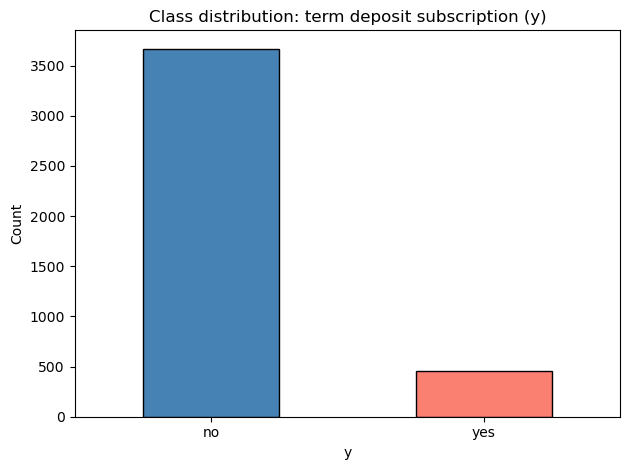

In [82]:
print(df["y"].value_counts())                    # count how many yes and no in the target variable
print(df["y"].value_counts(normalize=True))      # show the proportion of each class

df["y"].value_counts().plot(kind="bar",          # bar chart of the target variable
                             color=["steelblue", "salmon"],
                             edgecolor="black")
plt.title("Class distribution: term deposit subscription (y)")  # chart title
plt.xlabel("y")         # x-axis label
plt.ylabel("Count")     # y-axis label
plt.xticks(rotation=0)  # keep x-axis labels horizontal
plt.tight_layout()
plt.show()

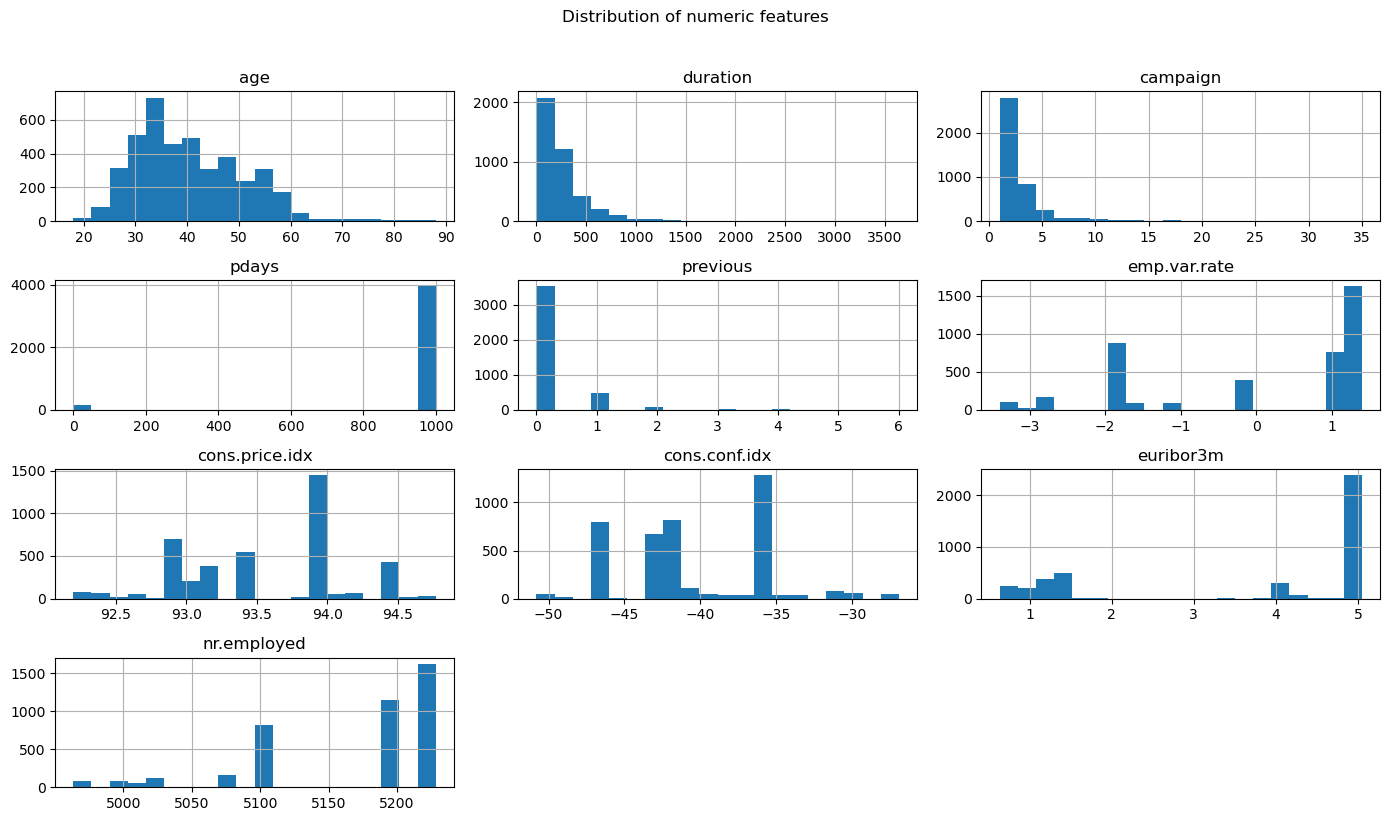

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

job:
job
admin.           1012
blue-collar       884
technician        691
services          393
management        324
retired           166
self-employed     159
entrepreneur      148
unemployed        111
housemaid         110
student            82
unknown            39
Name: count, dtype: int64

marital:
marital
married     2509
single      1153
divorced     446
unknown       11
Name: count, dtype: int64

education:
education
university.degree      1264
high.school             921
basic.9y                574
professional.course     535
basic.4y                429
basic.6y                228
unknown                 167
illiterate                1
Name: count, dtype: int64

default:
default
no         3315
unknown     803
yes           1
Name: count, dtype: int64

housing:
housing
yes        2175
no         1839
unknown     105
Name: count, dtype: int

In [83]:
df.select_dtypes(include=np.number).hist(figsize=(14, 8), bins=20)  # histogram for all numeric columns
plt.suptitle("Distribution of numeric features", y=1.02)            # overall title for the histograms
plt.tight_layout()
plt.show()

cat_cols = df.select_dtypes(include="object").columns.tolist()  # get all categorical column names
print("Categorical columns:", cat_cols)                         # print them for inspection

for col in cat_cols:                               # loop through each categorical column
    print(f"\n{col}:")                            # print column name as header
    print(df[col].value_counts())                  # count frequency of each category

In [87]:
#3b)
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

df = pd.read_csv(r"C:\Users\11317\Downloads\bank-additional.csv", sep=";")

df["y"] = df["y"].map({"yes": 1, "no": 0})  # encode target variable: yes = 1, no = 0


ohe_cols = ["marital", "contact", "poutcome", "day_of_week", "month"]  # columns to one-hot encode
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=float)  # create dummy variables, drop first to avoid multicollinearity


le = LabelEncoder()                                        # initialise label encoder
for col in ["job", "education", "housing", "loan", "default"]:  # loop through columns to label encode
    df[col] = le.fit_transform(df[col].astype(str))        # convert each category to an integer


scaler_std = StandardScaler()                              # initialise standard scaler (mean=0, std=1)
std_cols = ["age", "duration", "campaign", "previous",
            "emp.var.rate", "cons.price.idx",
            "cons.conf.idx", "euribor3m", "nr.employed"]   # columns to standardise
df[std_cols] = scaler_std.fit_transform(df[std_cols])      # fit and apply standardisation

# Min-Max scaling for pdays (bounded 0-1)
scaler_mm = MinMaxScaler()                                 # initialise min-max scaler (range 0 to 1)
df[["pdays"]] = scaler_mm.fit_transform(df[["pdays"]])     # fit and apply min-max scaling

print(df.shape)   # confirm shape after preprocessing
df.head()         # preview preprocessed data

(4119, 35)


,age,job,education,default,housing,loan,duration,campaign,pdays,previous,...,day_of_week_wed,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,-0.980752,1,2,0,2,0,0.903952,-0.209228,1.0,-0.351356,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.107991,7,3,0,0,0,0.350300,0.569634,1.0,-0.351356,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-1.465619,7,3,0,2,0,-0.116966,-0.598660,1.0,-0.351356,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-0.204965,7,2,0,1,1,-0.941553,0.180203,1.0,-0.351356,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.667795,0,6,0,2,0,-0.780563,-0.598660,1.0,-0.351356,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [88]:
#3c)

# Three algorithms chosen:
#   1. Logistic Regression  - standard baseline for binary classification; fast and interpretable
#   2. Random Forest        - ensemble method; robust to class imbalance and non-linear relationships
#   3. SVM (SVC)            - effective in high-dimensional spaces; used in E6 with class_weight='balanced'

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score

y = df["y"]                    # set target variable
X = df.drop(columns=["y"])     # set all other columns as features

# Train / Validation / Test split (60 / 20 / 20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)           # first split: hold out 20% as test set

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42) # second split: 25% of remaining 80% -> validation (= 20% overall)

print("Train:", X_train.shape[0],
      " Val:", X_val.shape[0],
      " Test:", X_test.shape[0])  # confirm sizes of each split

# Model 1: Logistic Regression with hyperparameter tuning
param_lr = {"C": [0.01, 0.1, 1, 10]}              # C controls regularisation strength
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000,               # increase max iterations to ensure convergence
                       class_weight="balanced",     # adjust weights to handle class imbalance
                       random_state=42),
    param_lr, cv=5, scoring="f1", n_jobs=-1)        # 5-fold CV, optimise for F1, use all CPU cores
grid_lr.fit(X_train, y_train)                       # fit on training set
print("Best LR params:", grid_lr.best_params_)      # print best hyperparameters found
y_pred_lr = grid_lr.best_estimator_.predict(X_val)  # predict on validation set
print(f"LR  Val F1: {f1_score(y_val, y_pred_lr):.4f}")  # report validation F1

# Model 2: Random Forest with hyperparameter tuning 
param_rf = {
    "n_estimators": [100, 200, 300],   # number of trees in the forest
    "max_depth":    [5, 10, None],     # maximum depth of each tree; None means unlimited
    "bootstrap":    [True, False]      # whether to use bootstrap sampling
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf, cv=5, scoring="f1", n_jobs=-1)         # 5-fold CV, optimise for F1
grid_rf.fit(X_train, y_train)                        # fit on training set
print("Best RF params:", grid_rf.best_params_)       # print best hyperparameters found
y_pred_rf = grid_rf.best_estimator_.predict(X_val)   # predict on validation set
print(f"RF  Val F1: {f1_score(y_val, y_pred_rf):.4f}")   # report validation F1

# Model 3: SVM with hyperparameter tuning
param_svm = {
    "C":      [0.1, 1, 10],             # regularisation parameter
    "gamma":  ["scale", 0.01, 0.1],    # kernel coefficient
    "kernel": ["rbf"]                   # radial basis function kernel
}
grid_svm = GridSearchCV(
    SVC(random_state=42, class_weight="balanced"),  # balanced handles class imbalance
    param_svm, cv=5, scoring="f1", n_jobs=-1)        # 5-fold CV, optimise for F1
grid_svm.fit(X_train, y_train)                       # fit on training set
print("Best SVM params:", grid_svm.best_params_)     # print best hyperparameters found
y_pred_svm = grid_svm.best_estimator_.predict(X_val) # predict on validation set
print(f"SVM Val F1: {f1_score(y_val, y_pred_svm):.4f}")  # report validation F1

Train: 2471  Val: 824  Test: 824
Best LR params: {'C': 10}
LR  Val F1: 0.5818
Best RF params: {'bootstrap': False, 'max_depth': None, 'n_estimators': 200}
RF  Val F1: 0.4342
Best SVM params: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
SVM Val F1: 0.5784


In [89]:
# 3d) Compare train/val/test split vs. cross-validation

from sklearn.model_selection import cross_val_score

best_lr  = grid_lr.best_estimator_   # retrieve best Logistic Regression model
best_rf  = grid_rf.best_estimator_   # retrieve best Random Forest model
best_svm = grid_svm.best_estimator_  # retrieve best SVM model

print(f"{'Model':<22} {'Val-set F1':>12} {'CV F1 (mean)':>14} {'CV F1 (std)':>12}")
print("-" * 62)

for name, model, y_pred_val in [
    ("Logistic Regression", best_lr,  y_pred_lr),
    ("Random Forest",       best_rf,  y_pred_rf),
    ("SVM",                 best_svm, y_pred_svm)
]:
    val_f1 = f1_score(y_val, y_pred_val)               # F1 on the held-out validation set
    cv_scores = cross_val_score(
        model, X_train, y_train, cv=5, scoring="f1")   # 5-fold CV on training data
    print(f"{name:<22} {val_f1:>12.4f} {cv_scores.mean():>14.4f} {cv_scores.std():>12.4f}")

# The val-set F1 depends on a single random split and can vary with random_state.
# The CV F1 averages over five folds and is therefore a more stable estimate of generalisation.
# If val-set and CV F1 differ noticeably, CV is the more reliable indicator.

Model                    Val-set F1   CV F1 (mean)  CV F1 (std)
--------------------------------------------------------------
Logistic Regression          0.5818         0.5829       0.0371
Random Forest                0.4342         0.5073       0.0834
SVM                          0.5784         0.5587       0.0288


Cross-validation gives a more stable estimate of generalisation performance than a single val-set split, particularly for Random Forest, where the two estimates diverge by 0.07. Logistic Regression and SVM show consistent results across both methods, suggesting the val-set split is reasonably representative for those models.

Model                    Accuracy  Precision   Recall       F1
--------------------------------------------------------------
Logistic Regression        0.8459     0.4074   0.8370   0.5480
Random Forest              0.8993     0.5672   0.4130   0.4780
SVM                        0.8301     0.3812   0.8370   0.5238


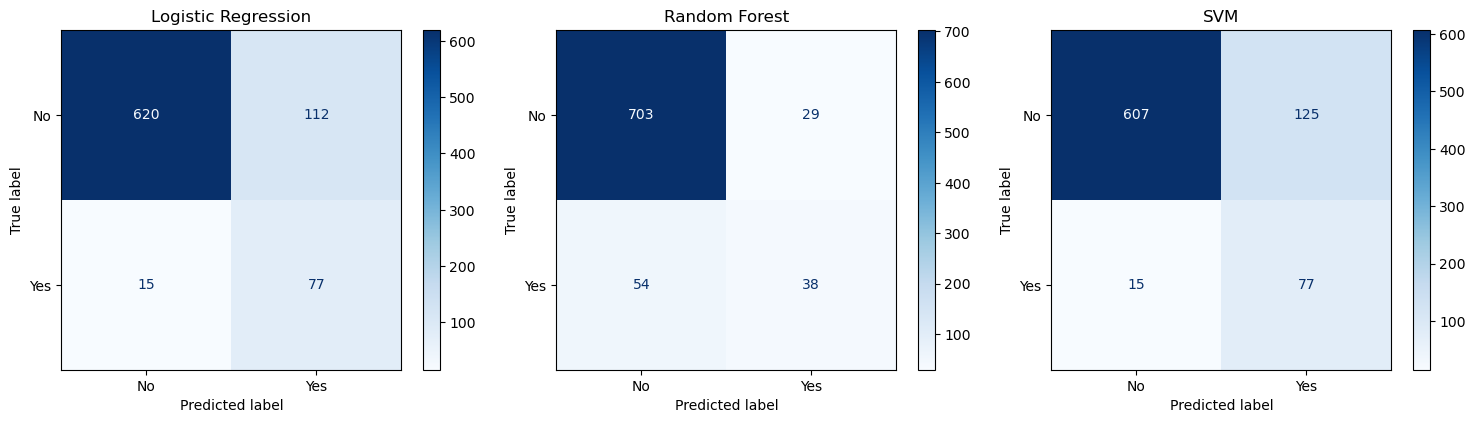


Best model: Logistic Regression (Test F1 = 0.5480)


In [90]:
# 3e) Final evaluation on test set and model selection

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

models = [
    ("Logistic Regression", best_lr),
    ("Random Forest",       best_rf),
    ("SVM",                 best_svm)
]

# Evaluate each model on the test set
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 62)

results = {}  # store results for model comparison

for name, model in models:
    y_pred = model.predict(X_test)                          # generate predictions on the test set
    acc  = accuracy_score(y_test, y_pred)                   # proportion of correct predictions
    prec = precision_score(y_test, y_pred)                  # of all predicted yes, how many are actually yes
    rec  = recall_score(y_test, y_pred)                     # of all actual yes, how many did the model catch
    f1   = f1_score(y_test, y_pred)                         # harmonic mean of precision and recall
    results[name] = {"f1": f1, "recall": rec, "pred": y_pred}
    print(f"{name:<22} {acc:>10.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f}")

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))             # create one subplot per model
for ax, (name, model) in zip(axes, models):
    cm = confusion_matrix(y_test, results[name]["pred"])    # compute confusion matrix
    ConfusionMatrixDisplay(
        cm, display_labels=["No", "Yes"]).plot(
        ax=ax, cmap="Blues")                                 # plot with blue colour scale
    ax.set_title(name)                                       # set subplot title
plt.tight_layout()
plt.show()

# Model selection
# With class imbalance (~89% no), accuracy is misleading.
# Recall matters most: we want to identify customers likely to subscribe.
# F1 balances precision and recall and is the primary selection criterion.
best_name = max(results, key=lambda k: results[k]["f1"])    # select model with highest test F1
print(f"\nBest model: {best_name} (Test F1 = {results[best_name]['f1']:.4f})")

Random Forest has the highest accuracy (0.90) but the lowest recall (0.41), meaning it fails to identify most customers who would subscribe. In a marketing context, missing a potential subscriber is more costly than contacting a non-subscriber. Recall and F1 are therefore the relevant metrics. Logistic Regression achieves the highest F1 (0.548) and the highest recall (0.837), correctly identifying 77 out of 92 actual subscribers in the test set. It is therefore the best model for this task.